In [54]:
from pathlib import Path

project_root = Path(".").resolve().parent.parent.parent
assert project_root.name == "pep-compass"

In [55]:
import pandas as pd

parents = pd.read_csv(
    project_root
    / "results/data/veltri_negative.csv"
)
mutants = pd.read_csv(
    project_root
    / "results/data/mutants/veltri_negative/veltri_negative_direction_threshold=0.001_token_threshold=0.1_jacobian_mode=approx.csv"
)

In [56]:
display(parents.head())
display(mutants.head())

,Name,Sequence,A. baumannii ATCC 19606,E. coli ATCC 11775,E. coli AIG221,E. coli AIG222,K. pneumoniae ATCC 13883,P. aeruginosa PA01,P. aeruginosa PA14,S. aureus ATCC 12600,...,B. ovatus ATCC8483,E. rectale ATCC33656,C. symbiosum,R. obeum,R. torques,E. coli Nissle,Salmonella enterica ATCC 9150 (BEIRES NR-515),Salmonella enterica (BEIRES NR-170),Salmonella enterica ATCC 9150 (BEIRES NR-174),L. monocytogenes ATCC 19111 (BEIRES NR-106)
0,UniRef50_A0QYG2,EGAVSGVEGLPSGSAL,138.511180,139.801180,137.902370,140.05830,138.364410,137.98553,136.774020,141.596900,...,408.06840,299.70337,142.26360,141.87341,134.63571,2463.8271,106.403625,1105.36780,646.91650,131.340040
1,UniRef50_Q9FKB0,ELIDRCIGSKIWVIMKGDKELVGILKG,89.528824,118.419390,119.541725,128.80423,100.891540,90.99354,102.825260,70.190704,...,252.05864,210.20215,129.42552,130.82336,113.55690,1169.5818,61.302850,516.47375,488.59735,83.926080
2,UniRef50_P33768,QNIQDRIKMYIKKEEEEPTNFKNPF,130.894900,115.837326,114.040790,131.67166,119.030320,124.43645,127.947815,118.429825,...,396.36917,304.71548,133.56018,129.68240,100.20509,1961.2029,79.325660,943.49840,455.85287,114.144104
3,UniRef50_O42888,GEGITPANIAISWAVKRGTSVLPKSVNESRIVS,134.440840,133.998600,130.942200,133.20078,139.556900,138.98576,135.156510,126.896560,...,425.77026,311.65692,138.77722,139.58517,133.83589,2635.2510,103.507120,1179.88680,699.80206,126.254190
4,UniRef50_P51657,GCSSGIGLHLAVRLASDRSQSFKVYATLRDLKSQGPLLEAARA,115.702190,121.632590,119.013330,127.29396,122.310265,120.87968,124.867210,95.488450,...,372.47662,279.35890,136.31871,129.34870,119.17818,2587.9010,87.836210,1226.76670,667.98175,109.741745


,mutant,position,parent,direction_significance_threshold,token_threshold,parent_name,parent_sequence,A. baumannii ATCC 19606,E. coli ATCC 11775,E. coli AIG221,...,B. ovatus ATCC8483,E. rectale ATCC33656,C. symbiosum,R. obeum,R. torques,E. coli Nissle,Salmonella enterica ATCC 9150 (BEIRES NR-515),Salmonella enterica (BEIRES NR-170),Salmonella enterica ATCC 9150 (BEIRES NR-174),L. monocytogenes ATCC 19111 (BEIRES NR-106)
0,EGAVSGVEGLPSGSAL,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2,EGAVSGVEGLPSGSAL,138.51120,139.80118,137.90237,...,408.06845,299.70350,142.26358,141.87337,134.63573,2463.8271,106.403660,1105.3683,646.91644,131.34004
1,EGAVSGVEGLPSGSAN,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2,EGAVSGVEGLPSGSAL,139.28995,140.26088,138.06827,...,425.31943,311.48676,143.79056,144.51553,138.30191,2539.0486,108.815346,1091.2412,676.61480,133.30217
2,EGAVSGVEGLPSGSAL,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2,EGAVSGVEGLPSGSAL,138.51120,139.80118,137.90237,...,408.06845,299.70350,142.26358,141.87337,134.63573,2463.8271,106.403660,1105.3683,646.91644,131.34004
3,EGAVSGVEGLPSGSAN,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2,EGAVSGVEGLPSGSAL,139.28995,140.26088,138.06827,...,425.31943,311.48676,143.79056,144.51553,138.30191,2539.0486,108.815346,1091.2412,676.61480,133.30217
4,EGAVSGVEGLPSGSAL,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2,EGAVSGVEGLPSGSAL,138.51120,139.80118,137.90237,...,408.06845,299.70350,142.26358,141.87337,134.63573,2463.8271,106.403660,1105.3683,646.91644,131.34004


In [57]:
import numpy as np
from typing import Literal, Optional


def compute_diff(
    parents_df: pd.DataFrame,
    mutants_df: pd.DataFrame,
    match_col_parents: str,
    match_col_mutants: str,
    value_cols: list[str],
    value_preprocessing: Optional[Literal["log"]],
    add_relative: bool,
) -> pd.DataFrame:
    """
    Compute the difference between the mutants and parents for each value column.
    """
    merged = mutants_df.merge(
        parents_df,
        left_on=match_col_mutants,
        right_on=match_col_parents,
        suffixes=("_mutants", "_parents"),
    )
    if value_preprocessing is None:
        vprep_fn = lambda x: x
    elif value_preprocessing == "log":
        vprep_fn = np.log2
    else:
        raise ValueError(f"Invalid value_preprocessing: {value_preprocessing}")
    if value_preprocessing is None:
        value_preprocessing = ""
    else:
        value_preprocessing = "_" + value_preprocessing

    for value_col in value_cols:
        merged[f"{value_col}{value_preprocessing}_diff"] = vprep_fn(
            merged[f"{value_col}_mutants"]
        ) - vprep_fn(merged[f"{value_col}_parents"])
        if add_relative:
            merged[f"{value_col}{value_preprocessing}_diff_relative"] = merged[
                f"{value_col}{value_preprocessing}_diff"
            ] / vprep_fn(merged[f"{value_col}_parents"])
    return merged

In [58]:
mic_bac_columns = parents.head().columns.tolist()[2:]

In [59]:
diff = compute_diff(
    parents_df=parents,
    mutants_df=mutants,
    match_col_parents="Name",
    match_col_mutants="parent_name",
    value_cols=mic_bac_columns,
    value_preprocessing="log",
    add_relative=True,
)

In [60]:
diff

,mutant,position,parent,direction_significance_threshold,token_threshold,parent_name,parent_sequence,A. baumannii ATCC 19606_mutants,E. coli ATCC 11775_mutants,E. coli AIG221_mutants,...,E. coli Nissle_log_diff,E. coli Nissle_log_diff_relative,Salmonella enterica ATCC 9150 (BEIRES NR-515)_log_diff,Salmonella enterica ATCC 9150 (BEIRES NR-515)_log_diff_relative,Salmonella enterica (BEIRES NR-170)_log_diff,Salmonella enterica (BEIRES NR-170)_log_diff_relative,Salmonella enterica ATCC 9150 (BEIRES NR-174)_log_diff,Salmonella enterica ATCC 9150 (BEIRES NR-174)_log_diff_relative,L. monocytogenes ATCC 19111 (BEIRES NR-106)_log_diff,L. monocytogenes ATCC 19111 (BEIRES NR-106)_log_diff_relative
0,EGAVSGVEGLPSGSAL,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2,EGAVSGVEGLPSGSAL,138.511200,139.801180,137.902370,...,0.000000,0.000000,4.745545e-07,7.047766e-08,6.525858e-07,6.454656e-08,-1.338066e-07,-1.433012e-08,0.000000,0.000000
1,EGAVSGVEGLPSGSAN,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2,EGAVSGVEGLPSGSAL,139.289950,140.260880,138.068270,...,0.043387,0.003851,3.233473e-02,4.802137e-03,-1.855647e-02,-1.835401e-03,6.475522e-02,6.935012e-03,0.021393,0.003040
2,EGAVSGVEGLPSGSAL,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2,EGAVSGVEGLPSGSAL,138.511200,139.801180,137.902370,...,0.000000,0.000000,4.745545e-07,7.047766e-08,6.525858e-07,6.454656e-08,-1.338066e-07,-1.433012e-08,0.000000,0.000000
3,EGAVSGVEGLPSGSAN,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2,EGAVSGVEGLPSGSAL,139.289950,140.260880,138.068270,...,0.043387,0.003851,3.233473e-02,4.802137e-03,-1.855647e-02,-1.835401e-03,6.475522e-02,6.935012e-03,0.021393,0.003040
4,EGAVSGVEGLPSGSAL,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2,EGAVSGVEGLPSGSAL,138.511200,139.801180,137.902370,...,0.000000,0.000000,4.745545e-07,7.047766e-08,6.525858e-07,6.454656e-08,-1.338066e-07,-1.433012e-08,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250859,GWAYKTVQEEDLPFPLIYG,12,GWAYKTVQEEDLKFPLIYG,0.001,0.1,UniRef50_Q05AL2,GWAYKTVQEEDLKFPLIYG,134.072510,134.489000,129.866320,...,0.506693,0.046960,1.479067e-01,2.253612e-02,9.700860e-02,9.561742e-03,1.960182e-01,2.125542e-02,0.143965,0.021226
250860,GWAYKTVQELDLKFPLIYG,9,GWAYKTVQEEDLKFPLIYG,0.001,0.1,UniRef50_Q05AL2,GWAYKTVQEEDLKFPLIYG,123.425930,129.777940,121.619040,...,0.180017,0.016684,-5.080759e-02,-7.741409e-03,-5.282761e-03,-5.207002e-04,1.659422e-02,1.799410e-03,-0.062845,-0.009266
250861,GWAYKTVQEEDLKFPLIRG,17,GWAYKTVQEEDLKFPLIYG,0.001,0.1,UniRef50_Q05AL2,GWAYKTVQEEDLKFPLIYG,119.093765,124.244995,117.214294,...,-0.388272,-0.035985,-1.345182e-01,-2.049615e-02,-2.003283e-01,-1.974555e-02,-1.255190e-01,-1.361078e-02,-0.115670,-0.017054
250862,GWAYKTVQEEDLKFPIIYG,15,GWAYKTVQEEDLKFPLIYG,0.001,0.1,UniRef50_Q05AL2,GWAYKTVQEEDLKFPLIYG,126.570755,130.751600,124.777610,...,0.050731,0.004702,4.695143e-03,7.153857e-04,2.098050e-02,2.067962e-03,2.223319e-02,2.410878e-03,0.019332,0.002850


In [61]:
import pandas as pd
import numpy as np

ALL_AA = list("ACDEFGHIKLMNPQRSTVWY")


diff_clean = diff.dropna(subset=["parent", "mutant", "position"]).drop_duplicates(subset=["parent", "mutant", "position"])


mask = (
    (diff_clean["position"] < diff_clean["parent"].str.len()) &
    (diff_clean["position"] < diff_clean["mutant"].str.len())
)
diff_clean = diff_clean[mask]

delta_cols = [col for col in diff.columns if col.endswith("_diff")]

diff_clean["parent_aa"] = diff_clean.apply(lambda r: r["parent"][r["position"]], axis=1)
diff_clean["mutant_aa"] = diff_clean.apply(lambda r: r["mutant"][r["position"]], axis=1)

diff_clean = diff_clean[diff_clean["parent_aa"] != diff_clean["mutant_aa"]]

mutation_matrix = pd.DataFrame(
    [[[] for _ in ALL_AA] for _ in ALL_AA],
    index=ALL_AA,
    columns=ALL_AA
)

for aa_pair, group in diff_clean.groupby(["parent_aa", "mutant_aa"]):
    p_aa, m_aa = aa_pair
    mutation_matrix.at[p_aa, m_aa] = group[delta_cols].to_numpy()


example_list = mutation_matrix.at["A", "T"]


In [62]:
example_list = mutation_matrix.at["A", "C"]
example_list.shape
# example_list

(28, 34)

In [63]:
# Prepare empty mean matrix

mean_diffs_matrix = pd.DataFrame(
    [[None for _ in ALL_AA] for _ in ALL_AA],
    index=ALL_AA,
    columns=ALL_AA
)

# Compute mean ΔMIC per mutation cell
for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        vectors = mutation_matrix.at[p_aa, m_aa]  # list of ΔMIC vectors
        if len(vectors) > 0:
            mean_diffs_matrix.at[p_aa, m_aa] = np.mean(vectors, axis=0)  # mean per bacterium
        else:
            mean_diffs_matrix.at[p_aa, m_aa] = np.zeros(len(delta_cols))  # or np.nan

In [64]:
mic_bac_columns

['A. baumannii ATCC 19606',
 'E. coli ATCC 11775',
 'E. coli AIG221',
 'E. coli AIG222',
 'K. pneumoniae ATCC 13883',
 'P. aeruginosa PA01',
 'P. aeruginosa PA14',
 'S. aureus ATCC 12600',
 'S. aureus (ATCC BAA-1556) - MRSA',
 'vancomycin-resistant E. faecalis ATCC 700802',
 'vancomycin-resistant E. faecium ATCC 700221',
 'A. muciniphila ATCC BAA-835',
 'B. fragilis ATCC25285',
 'B. vulgatus ATCC8482',
 'C. aerofaciens ATCC25986',
 'C. scindens ATCC35704',
 'B. thetaiotaomicron ATCC29148',
 'B. thetaiotaomicron Complemmented',
 'B. thetaiotaomicron Mutant',
 'B. uniformis ATCC8492',
 'B. eggerthi ATCC27754',
 'C. spiroforme ATCC29900',
 'P. distasonis ATCC8503',
 'P. copri DSMZ18205',
 'B. ovatus ATCC8483',
 'E. rectale ATCC33656',
 'C. symbiosum',
 'R. obeum',
 'R. torques',
 'E. coli Nissle',
 'Salmonella enterica ATCC 9150 (BEIRES NR-515)',
 'Salmonella enterica (BEIRES NR-170)',
 'Salmonella enterica ATCC 9150 (BEIRES NR-174)',
 'L. monocytogenes ATCC 19111 (BEIRES NR-106)']

In [65]:
gram_neg = [0,1,2,3,4,5,6,11,12,13,16,17,18,19,20,22,23,24,29,30,31,32]
gram_pos = [7,8,9,10,14,15,21,25,26,27,28,33]

In [66]:
##having mutation_matrix, make histogram plot of mean values for gram_pos and gram_neg for each entry of mutation matrix
gram_means = pd.DataFrame(index=ALL_AA, columns=ALL_AA, dtype=object)
AA_bins = [ALL_AA[i:i+5] for i in range(0, 20, 5)]
for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        arr = mutation_matrix.at[p_aa, m_aa]
        if isinstance(arr, np.ndarray) and arr.size > 0 and arr.ndim == 2:
            # mean over bacteria within each group → one value per mutation
            gram_neg_means = np.nanmean(arr[:, gram_neg], axis=1)
            gram_pos_means = np.nanmean(arr[:, gram_pos], axis=1)
            gram_means.at[p_aa, m_aa] = (gram_neg_means, gram_pos_means)
        else:
            gram_means.at[p_aa, m_aa] = ([], [])

In [67]:
gram_means

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
A,"([], [])","([-0.0036370690231362283, 0.01696622120108593,...","([0.007987152973385843, 0.004656040264382105, ...","([0.0027469353003721168, -0.02010906210490848,...","([0.002722402014377436, -0.01800345030785239, ...","([0.0008232417823244424, 0.016693443059230748,...","([-0.0031320128350512777, -0.00729309057463172...","([-0.008635479567616273, -0.03156955101756456,...","([-0.018038304488209735, -0.005913402384697296...","([-0.011817971448011473, -0.001790776122925179...","([0.019827637077353355, 0.005030289661356809, ...","([-0.00734680956120114, -0.024591651524205525,...","([0.0033967849778918546, -6.927762471137748e-0...","([-0.016857275568902465, -0.026998958278439848...","([-0.022624311570116514, -0.006852680245561637...","([0.0142555115122047, 0.0026400949561126053, -...","([0.004718597275618216, 0.007088075535184313, ...","([-0.0010872364491417404, -0.00367608098838643...","([-0.002817232836927, 0.0036272136113345466, -...","([0.001110284486962679, 0.00871472782625596, 0..."
C,"([0.001078425210577065, -0.0028515782123775713...","([], [])","([0.007966730716786531, 0.002569793183280292, ...","([0.00656053190745168, -0.002258735539047803, ...","([0.001878381877451162, -0.004041470642278485,...","([0.012421363001067099, 0.00045740516338543813...","([0.04037292064478925, 0.020716338658448817, 0...","([-0.0033476078690196946, -0.06086979102246741...","([-0.0034138265534596453, -0.02800087473321828...","([0.0001916611996399001, -0.000120970760062657...","([0.008774446284215682, -0.01443576996613307, ...","([-0.0009793239116473048, -0.00570198687787147...","([0.0012197158101416054, 0.0021391276821391566...","([-0.08345035413622158, 0.010935295358868754, ...","([-0.008185156035471158, -0.12486457512442244,...","([0.0161745130520773, -0.0005733947271028373, ...","([0.008306647723414606, 0.0005961173080559364,...","([0.014573787052913617, -0.0018912057291506509...","([-0.012854499392357489, 0.000451143091310295]...","([-0.00036511453708178783, -0.0173884746211765..."
D,"([-0.18796414125231883, -0.05556092733377659, ...","([0.003657031629819149, -0.003911251970581165,...","([], [])","([-0.05072361337878069, -0.010826708119694016,...","([-0.0023162338728546835, -0.02479253151410362...","([-0.1746684130207431, -0.044952249269763704, ...","([-0.12217469973329126, -0.010898575107487728,...","([-0.13847886435743353, -0.005525135325398767,...","([-0.038556810348516386, -0.025798535719244228...","([-0.018951356977844558, -0.002065140428167058...","([0.006408438916363183, -0.0005629649708273166...","([-0.017562495676277736, -0.002423737028151281...","([0.0005111401734706175, -0.003610219977679175...","([0.0003314751426943213, -0.01605205810820929,...","([-0.005532528490502403, -0.04575663986057821,...","([-0.13721845027030585, -0.05447465368058856, ...","([-0.0026984912652891035, -5.667336754365916e-...","([-0.2370507731171127, -0.020298435250756697, ...","([-0.009522827563432883, -0.020216067717454243...","([0.0002311479348932156, 0.0016849212812361665..."
E,"([0.012269291128208192, -0.021555637528277615,...","([-0.028383047128815262, 0.07013368001201177, ...","([0.006101339999642272, -0.016541396112741857,...","([], [])","([0.0028605010338304286, -0.06631637225852792,...","([-0.01172145927140076, -0.06828194297180304, ...","([0.025070544828719035, -0.027073721342021875,...","([-0.017524447435694427, -0.05730891379394156,...","([-0.028112015102473468, -0.0546283495027142, ...","([-0.018381142294726385, -0.001177779137565580...","([-0.024496008513813082, -0.029932793711466236...","([-0.01218262376609794, -0.03878838151014891, ...","([-0.00030263453290337657, -0.0269841141680973...","([-0.014763295743710391, -0.024253143149166802...","([-0.05222001609773918, -0.001913650162606715,...","([0.012728425916063863, 0.003562435884764348, ...","([-0.0007063208488063663, -0.00442476334013425...","([-0.040260151232218426, -0.01940528032800628,...","([-0.09326985057383458, -0.10950370552581346, ...","([-0.0

In [84]:
import os
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
n_bac = None
for p in ALL_AA:
    for m in ALL_AA:
        cell = mutation_matrix.at[p, m]
        if isinstance(cell, np.ndarray) and cell.size > 0:
            if cell.ndim == 2:
                n_bac = cell.shape[1]
                break
    if n_bac is not None:
        break

if n_bac is None:
    raise ValueError("Couldn't infer number of bacteria from mutation_matrix (all entries empty).")

print(f"Detected number of bacteria (columns) = {n_bac}")

# Validate Gram index lists (clip out-of-range indices and warn)
def validate_indices(name, idx_list):
    valid = [i for i in idx_list if 0 <= i < n_bac]
    removed = [i for i in idx_list if i not in valid]
    if removed:
        print(f"Warning: removed out-of-range indices from {name}: {removed}")
    if len(valid) == 0:
        raise ValueError(f"After validation, {name} is empty. Cannot proceed.")
    return valid

gram_neg = validate_indices("gram_neg", gram_neg)
gram_pos = validate_indices("gram_pos", gram_pos)

# prepare AA bins: 4 bins of 5 AA each
AA_bins = [ALL_AA[i:i+5] for i in range(0, 20, 5)]

# directory to save figures
outdir = "aa_block_plots"
os.makedirs(outdir, exist_ok=True)

# helper to compute per-mutation means for Gram groups robustly
def compute_group_means(arr, gram_indices):
    """
    arr: np.ndarray shape (n_mutations, n_bacteria)
    gram_indices: list of column indices
    returns: 1D np.ndarray shape (n_mutations,) of mean across the specified bacteria
    """
    if not (isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.size > 0):
        return np.array([])
    # If there are NaNs, nanmean will handle them
    try:
        means = np.nanmean(arr[:, gram_indices], axis=1)
    except Exception:
        # in case arr has fewer cols than expected, return empty
        return np.array([])
    return means

# iterate over 4x4 blocks and build 5x5 plots per block
for i_block, p_block in enumerate(AA_bins):
    for j_block, m_block in enumerate(AA_bins):
        fig, axes = plt.subplots(5, 5, figsize=(16, 16))
        fig.suptitle(f"Block {i_block+1},{j_block+1} — Parents {p_block[0]}..{p_block[-1]} → Mutants {m_block[0]}..{m_block[-1]}", fontsize=14)
        
        # Flatten axes for easy indexing
        axes_flat = axes.flatten()
        
        for k, (p_aa) in enumerate(p_block):
            for l, (m_aa) in enumerate(m_block):
                ax_idx = k*5 + l
                ax = axes_flat[ax_idx]
                
                # get array for this pair
                arr = mutation_matrix.at[p_aa, m_aa]
                if not (isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.size > 0):
                    # empty -> mark and continue
                    ax.text(0.5, 0.5, f"{p_aa}→{m_aa}\n(empty)", ha='center', va='center', fontsize=10)
                    ax.set_xticks([])
                    ax.set_yticks([])
                    continue
                
                # compute per-mutation means across gram groups
                gn = compute_group_means(arr, gram_neg)  # length = n_mutations
                gp = compute_group_means(arr, gram_pos)  # length = n_mutations
                
                # if both are empty (shouldn't happen) mark
                if gn.size == 0 and gp.size == 0:
                    ax.text(0.5, 0.5, f"{p_aa}→{m_aa}\n(no valid group data)", ha='center', va='center', fontsize=9)
                    ax.set_xticks([])
                    ax.set_yticks([])
                    continue
                
                # hist plotting parameters
                bins = 25
                alpha = 0.35
                # hist (density=True so KDE overlay aligns)
                if gn.size > 0:
                    ax.hist(gn, bins=bins, density=True, alpha=alpha, label="Gram−" if ax_idx==0 else None)
                if gp.size > 0:
                    ax.hist(gp, bins=bins, density=True, alpha=alpha, label="Gram+" if ax_idx==0 else None)
                
                # KDE overlays (only if at least 2 unique points)
                try:
                    if gn.size >= 2 and np.nanstd(gn) > 0:
                        kde_gn = gaussian_kde(gn)
                    else:
                        kde_gn = None
                except Exception:
                    kde_gn = None
                try:
                    if gp.size >= 2 and np.nanstd(gp) > 0:
                        kde_gp = gaussian_kde(gp)
                    else:
                        kde_gp = None
                except Exception:
                    kde_gp = None
                
                # build x-range from combined non-nan values
                combined_vals = np.concatenate([x for x in [gn, gp] if x.size>0])
                if combined_vals.size > 0:
                    xmin, xmax = np.nanmin(combined_vals), np.nanmax(combined_vals)
                    # extend a bit for nicer KDE tails
                    pad = (xmax - xmin) * 0.08 if xmax > xmin else 0.5
                    xs = np.linspace(xmin - pad, xmax + pad, 200)
                else:
                    xs = np.linspace(-1, 1, 200)
                
                if kde_gn is not None:
                    ax.plot(xs, kde_gn(xs), lw=1.2, color='tab:blue')
                if kde_gp is not None:
                    ax.plot(xs, kde_gp(xs), lw=1.2, color='tab:orange')
                
                # subplot title: single mutation pair
                ax.set_title(f"{p_aa} → {m_aa}\n(n_mut={arr.shape[0]})", fontsize=9)
                ax.tick_params(axis="x", labelsize=7)
                ax.set_yticks([])
        
        # Add a single legend to the figure (outside the grid)
        handles = []
        labels = []
        handles.append(plt.Line2D([0], [0], color='tab:blue', lw=2))
        labels.append('Gram− KDE/hist')
        handles.append(plt.Line2D([0], [0], color='tab:orange', lw=2))
        labels.append('Gram+ KDE/hist')
        fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.93, 0.92), fontsize=10)
        
        plt.tight_layout(rect=[0, 0, 0.92, 0.96])
        
        outpath = os.path.join(outdir, f"aa_block_{i_block+1}_{j_block+1}.png")
        plt.savefig(outpath, dpi=300)
        plt.close(fig)
        print(f"Saved: {outpath}")

Detected number of bacteria (columns) = 34
Saved: aa_block_plots/aa_block_1_1.png
Saved: aa_block_plots/aa_block_1_2.png
Saved: aa_block_plots/aa_block_1_3.png
Saved: aa_block_plots/aa_block_1_4.png
Saved: aa_block_plots/aa_block_2_1.png
Saved: aa_block_plots/aa_block_2_2.png
Saved: aa_block_plots/aa_block_2_3.png
Saved: aa_block_plots/aa_block_2_4.png
Saved: aa_block_plots/aa_block_3_1.png
Saved: aa_block_plots/aa_block_3_2.png
Saved: aa_block_plots/aa_block_3_3.png
Saved: aa_block_plots/aa_block_3_4.png
Saved: aa_block_plots/aa_block_4_1.png
Saved: aa_block_plots/aa_block_4_2.png
Saved: aa_block_plots/aa_block_4_3.png
Saved: aa_block_plots/aa_block_4_4.png


In [82]:
import os
import matplotlib.pyplot as plt
import numpy as np # Added for good measure, assuming it's imported elsewhere or available
# from scipy.stats import gaussian_kde # Not needed for scatter plot
# Assuming ALL_AA, mutation_matrix, gram_neg, gram_pos are defined in the broader context

n_bac = None
for p in ALL_AA:
    for m in ALL_AA:
        cell = mutation_matrix.at[p, m]
        if isinstance(cell, np.ndarray) and cell.size > 0:
            if cell.ndim == 2:
                n_bac = cell.shape[1]
                break
    if n_bac is not None:
        break

if n_bac is None:
    raise ValueError("Couldn't infer number of bacteria from mutation_matrix (all entries empty).")

print(f"Detected number of bacteria (columns) = {n_bac}")

# Validate Gram index lists (clip out-of-range indices and warn)
def validate_indices(name, idx_list):
    valid = [i for i in idx_list if 0 <= i < n_bac]
    removed = [i for i in idx_list if i not in valid]
    if removed:
        print(f"Warning: removed out-of-range indices from {name}: {removed}")
    if len(valid) == 0:
        raise ValueError(f"After validation, {name} is empty. Cannot proceed.")
    return valid

# Ensure gram_neg and gram_pos are defined and accessible before this point
# Example placeholder if not:
# gram_neg = validate_indices("gram_neg", gram_neg_indices_list)
# gram_pos = validate_indices("gram_pos", gram_pos_indices_list)

gram_neg = validate_indices("gram_neg", gram_neg)
gram_pos = validate_indices("gram_pos", gram_pos)

# prepare AA bins: 4 bins of 5 AA each
AA_bins = [ALL_AA[i:i+5] for i in range(0, 20, 5)]

# directory to save figures - MODIFIED
outdir = "aa_scatters"
os.makedirs(outdir, exist_ok=True)

# helper to compute per-mutation means for Gram groups robustly
def compute_group_means(arr, gram_indices):
    """
    arr: np.ndarray shape (n_mutations, n_bacteria)
    gram_indices: list of column indices
    returns: 1D np.ndarray shape (n_mutations,) of mean across the specified bacteria
    """
    if not (isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.size > 0):
        return np.array([])
    # If there are NaNs, nanmean will handle them
    try:
        # Check if the indices are valid for the array shape
        if any(idx >= arr.shape[1] for idx in gram_indices):
             print(f"Error: Index out of bounds in arr[:, gram_indices]. arr.shape[1]={arr.shape[1]}")
             return np.array([])
        means = np.nanmean(arr[:, gram_indices], axis=1)
    except Exception as e:
        # in case arr has fewer cols than expected or other issue, return empty
        # print(f"Error computing group means: {e}")
        return np.array([])
    return means

# iterate over 4x4 blocks and build 5x5 plots per block
for i_block, p_block in enumerate(AA_bins):
    for j_block, m_block in enumerate(AA_bins):
        fig, axes = plt.subplots(5, 5, figsize=(16, 16))
        # Updated suptitle to reflect scatter plot
        fig.suptitle(f"Scatter Plot: Gram-Positive vs Gram-Negative Mean Values\nBlock {i_block+1},{j_block+1} — Parents {p_block[0]}..{p_block[-1]} → Mutants {m_block[0]}..{m_block[-1]}", fontsize=14)
        
        # Flatten axes for easy indexing
        axes_flat = axes.flatten()

        # Determine global plot limits for consistency across all 25 subplots
        # Need to pre-calculate min/max across ALL data in the 25-plot block
        # For simplicity and to avoid too many iterations, we'll collect all valid gn/gp
        # values in this block and determine limits from them.
        all_gn_gp_vals = []
        for p_aa in p_block:
            for m_aa in m_block:
                arr = mutation_matrix.at[p_aa, m_aa]
                if isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.size > 0:
                    gn_data = compute_group_means(arr, gram_neg)
                    gp_data = compute_group_means(arr, gram_pos)
                    # Only collect if both have data for a scatter plot point
                    if gn_data.size > 0 and gp_data.size > 0:
                        # Combine gn and gp data for valid (non-NaN, non-inf) points
                        # Assumes gn and gp are the same length (n_mutations)
                        valid_mask = np.isfinite(gn_data) & np.isfinite(gp_data)
                        all_gn_gp_vals.extend(gn_data[valid_mask])
                        all_gn_gp_vals.extend(gp_data[valid_mask])
        
        if all_gn_gp_vals:
            global_min = np.min(all_gn_gp_vals)
            global_max = np.max(all_gn_gp_vals)
            # Add some padding
            data_range = global_max - global_min if global_max > global_min else 1.0
            # limit_min = global_min - data_range * 0.05
            # limit_max = global_max + data_range * 0.05
            limit_min = -.2
            limit_max = .2
        else:
            # Default limits if no data found
            limit_min, limit_max = -0.1, 0.1 

        
        for k, (p_aa) in enumerate(p_block):
            for l, (m_aa) in enumerate(m_block):
                ax_idx = k*5 + l
                ax = axes_flat[ax_idx]
                
                # get array for this pair
                arr = mutation_matrix.at[p_aa, m_aa]
                if not (isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.size > 0):
                    # empty -> mark and continue
                    ax.text(0.5, 0.5, f"{p_aa}→{m_aa}\n(empty)", ha='center', va='center', fontsize=10)
                    ax.set_xticks([])
                    ax.set_yticks([])
                    ax.set_title(f"{p_aa} → {m_aa}", fontsize=9)
                    continue
                
                # compute per-mutation means across gram groups
                gn = compute_group_means(arr, gram_neg)  # length = n_mutations
                gp = compute_group_means(arr, gram_pos)  # length = n_mutations
                
                # Filter out NaNs/Infs for plotting
                if gn.size > 0 and gp.size > 0:
                    # Filter for points where both coordinates are valid numbers
                    valid_mask = np.isfinite(gn) & np.isfinite(gp)
                    gn_valid = gn[valid_mask]
                    gp_valid = gp[valid_mask]
                else:
                    gn_valid = np.array([])
                    gp_valid = np.array([])


                # if not enough paired data, mark
                if gn_valid.size == 0 or gp_valid.size == 0 or gn_valid.size != gp_valid.size:
                    ax.text(0.5, 0.5, f"{p_aa}→{m_aa}\n(no valid paired data)", ha='center', va='center', fontsize=9)
                    ax.set_xticks([])
                    ax.set_yticks([])
                    ax.set_title(f"{p_aa} → {m_aa}", fontsize=9)
                    continue

                # --- SCATTER PLOT MODIFICATION STARTS HERE ---
                
                # Scatter Plot (Gram-Neg mean on X, Gram-Pos mean on Y)
                ax.scatter(gn_valid, gp_valid, s=15, alpha=0.6, edgecolors='none', color='tab:green', label="Mutation Mean" if ax_idx==0 else None)
                
                # Add a 45-degree line (y=x) for comparison
                ax.plot([limit_min, limit_max], [limit_min, limit_max], 'k--', alpha=0.5, lw=1)
                
                # Set consistent axes limits
                ax.set_xlim(limit_min, limit_max)
                ax.set_ylim(limit_min, limit_max)
                ax.set_aspect('equal', adjustable='box') # Crucial for 45-degree line comparison
                
                # subplot title: single mutation pair
                ax.set_title(f"{p_aa} → {m_aa}\n(n_points={gn_valid.shape[0]})", fontsize=9)
                ax.tick_params(axis="both", labelsize=7)
                
                # Set X/Y labels only on the outside plots for clarity
                if k == 4: # Bottom row
                    ax.set_xlabel("Gram− Mean", fontsize=8)
                if l == 0: # Left column
                    ax.set_ylabel("Gram+ Mean", fontsize=8)
                else:
                    # Remove Y-ticks/labels from inner plots
                    ax.tick_params(axis='y', labelleft=False)

                # --- SCATTER PLOT MODIFICATION ENDS HERE ---
        
        # Add a single legend to the figure (outside the grid)
        handles = []
        labels = []
        # Legend for the scatter points
        handles.append(plt.Line2D([0], [0], marker='o', color='tab:green', linestyle='', markersize=5, alpha=0.6))
        labels.append('Per-Mutation Mean (Gram+ vs Gram-)')
        # Legend for the y=x line
        handles.append(plt.Line2D([0], [0], color='k', linestyle='--', lw=1))
        labels.append('Y = X (No Difference)')

        # Use a more central location for the legend, or omit if axes labels are clear enough
        # fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.93, 0.92), fontsize=10)
        
        # Simplified legend placed below the title
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.97), ncol=2, fontsize=10)

        plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust rect to make room for the legend/title
        
        outpath = os.path.join(outdir, f"aa_scatter_{i_block+1}_{j_block+1}.png") # MODIFIED file name
        plt.savefig(outpath, dpi=300)
        plt.close(fig)
        print(f"Saved: {outpath}")

Detected number of bacteria (columns) = 34
Saved: aa_scatters/aa_scatter_1_1.png
Saved: aa_scatters/aa_scatter_1_2.png
Saved: aa_scatters/aa_scatter_1_3.png
Saved: aa_scatters/aa_scatter_1_4.png
Saved: aa_scatters/aa_scatter_2_1.png
Saved: aa_scatters/aa_scatter_2_2.png
Saved: aa_scatters/aa_scatter_2_3.png
Saved: aa_scatters/aa_scatter_2_4.png
Saved: aa_scatters/aa_scatter_3_1.png
Saved: aa_scatters/aa_scatter_3_2.png
Saved: aa_scatters/aa_scatter_3_3.png
Saved: aa_scatters/aa_scatter_3_4.png
Saved: aa_scatters/aa_scatter_4_1.png
Saved: aa_scatters/aa_scatter_4_2.png
Saved: aa_scatters/aa_scatter_4_3.png
Saved: aa_scatters/aa_scatter_4_4.png


In [86]:
import os
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu # Import the nonparametric test

# Assuming ALL_AA, mutation_matrix, gram_neg, gram_pos are defined in the broader context

n_bac = None
for p in ALL_AA:
    for m in ALL_AA:
        cell = mutation_matrix.at[p, m]
        if isinstance(cell, np.ndarray) and cell.size > 0:
            if cell.ndim == 2:
                n_bac = cell.shape[1]
                break
    if n_bac is not None:
        break

if n_bac is None:
    raise ValueError("Couldn't infer number of bacteria from mutation_matrix (all entries empty).")

print(f"Detected number of bacteria (columns) = {n_bac}")

# Validate Gram index lists (clip out-of-range indices and warn)
def validate_indices(name, idx_list):
    valid = [i for i in idx_list if 0 <= i < n_bac]
    removed = [i for i in idx_list if i not in valid]
    if removed:
        print(f"Warning: removed out-of-range indices from {name}: {removed}")
    if len(valid) == 0:
        raise ValueError(f"After validation, {name} is empty. Cannot proceed.")
    return valid

# Assuming gram_neg and gram_pos indices lists are available
gram_neg = validate_indices("gram_neg", gram_neg)
gram_pos = validate_indices("gram_pos", gram_pos)

# prepare AA bins: 4 bins of 5 AA each
AA_bins = [ALL_AA[i:i+5] for i in range(0, 20, 5)]

# directory to save figures
outdir = "aa_scatters"
os.makedirs(outdir, exist_ok=True)

# helper to compute per-mutation means for Gram groups robustly
def compute_group_means(arr, gram_indices):
    """
    arr: np.ndarray shape (n_mutations, n_bacteria)
    gram_indices: list of column indices
    returns: 1D np.ndarray shape (n_mutations,) of mean across the specified bacteria
    """
    if not (isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.size > 0):
        return np.array([])
    try:
        if any(idx >= arr.shape[1] for idx in gram_indices):
             return np.array([])
        means = np.nanmean(arr[:, gram_indices], axis=1)
    except Exception:
        return np.array([])
    return means

# iterate over 4x4 blocks and build 5x5 plots per block
for i_block, p_block in enumerate(AA_bins):
    for j_block, m_block in enumerate(AA_bins):
        fig, axes = plt.subplots(5, 5, figsize=(16, 16))
        # Updated suptitle to reflect the statistical test addition
        fig.suptitle(f"Scatter Plot & Mann-Whitney U Test p-values\nBlock {i_block+1},{j_block+1} — Parents {p_block[0]}..{p_block[-1]} → Mutants {m_block[0]}..{m_block[-1]}", fontsize=14)
        
        # Flatten axes for easy indexing
        axes_flat = axes.flatten()

        # --- Determine global plot limits (repeated from previous version) ---
        all_gn_gp_vals = []
        for p_aa in p_block:
            for m_aa in m_block:
                arr = mutation_matrix.at[p_aa, m_aa]
                if isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.size > 0:
                    gn_data = compute_group_means(arr, gram_neg)
                    gp_data = compute_group_means(arr, gram_pos)
                    if gn_data.size > 0 and gp_data.size > 0:
                        valid_mask = np.isfinite(gn_data) & np.isfinite(gp_data)
                        all_gn_gp_vals.extend(gn_data[valid_mask])
                        all_gn_gp_vals.extend(gp_data[valid_mask])
        
        if all_gn_gp_vals:
            global_min = np.min(all_gn_gp_vals)
            global_max = np.max(all_gn_gp_vals)
            data_range = global_max - global_min if global_max > global_min else 1.0
            # limit_min = global_min - data_range * 0.05
            # limit_max = global_max + data_range * 0.05
            limit_min = -0.2
            limit_max = 0.2
        else:
            limit_min, limit_max = -0.1, 0.1 
        # --------------------------------------------------------------------
        
        for k, (p_aa) in enumerate(p_block):
            for l, (m_aa) in enumerate(m_block):
                ax_idx = k*5 + l
                ax = axes_flat[ax_idx]
                
                # get array for this pair
                arr = mutation_matrix.at[p_aa, m_aa]
                
                if not (isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.size > 0):
                    # empty -> mark and continue
                    ax.text(0.5, 0.5, f"{p_aa}→{m_aa}\n(empty)", ha='center', va='center', fontsize=10)
                    ax.set_xticks([])
                    ax.set_yticks([])
                    ax.set_title(f"{p_aa} → {m_aa}", fontsize=9)
                    continue
                
                # compute per-mutation means across gram groups
                gn = compute_group_means(arr, gram_neg)  # length = n_mutations
                gp = compute_group_means(arr, gram_pos)  # length = n_mutations
                
                # Filter out NaNs/Infs for plotting
                if gn.size > 0 and gp.size > 0:
                    valid_mask = np.isfinite(gn) & np.isfinite(gp)
                    gn_valid = gn[valid_mask]
                    gp_valid = gp[valid_mask]
                else:
                    gn_valid = np.array([])
                    gp_valid = np.array([])

                # --- Mann-Whitney U Test (Wilcoxon Rank-Sum) ---
                p_val_mw = np.nan
                u_stat_mw = np.nan
                test_label = "Insufficient data"
                
                # The Mann-Whitney U test compares the *two independent samples* (gn_data and gp_data) 
                # for the same set of N_mutations. 
                # This compares the distribution of all Gram-neg means against all Gram-pos means.
                # Crucially, the Mann-Whitney test should be applied to the original, full-size gn and gp arrays.
                
                # Re-check the full gn and gp (before paired filtering) for the test
                # Ensure we only use finite, non-zero-length arrays for the test
                gn_full = compute_group_means(arr, gram_neg)
                gp_full = compute_group_means(arr, gram_pos)
                
                # Clean the full arrays of NaNs/Infs before the test
                gn_clean = gn_full[np.isfinite(gn_full) & (gn_full.size > 0)]
                gp_clean = gp_full[np.isfinite(gp_full) & (gp_full.size > 0)]

                # Require at least a few points in each group to run the test robustly (e.g., 5)
                if gn_clean.size >= 5 and gp_clean.size >= 5:
                    try:
                        u_stat_mw, p_val_mw = mannwhitneyu(gn_clean, gp_clean, alternative='two-sided', method='auto')
                        
                        # Add significance stars for clarity
                        if p_val_mw < 0.001:
                            star = '***'
                        elif p_val_mw < 0.01:
                            star = '**'
                        elif p_val_mw < 0.05:
                            star = '*'
                        else:
                            star = 'ns'
                            
                        test_label = f"p={p_val_mw:.3f}{star} (n={gn_clean.size}, {gp_clean.size})"
                    except ValueError:
                        # Happens if all values are identical or if the sample is too small/degenerate for 'auto' method
                        test_label = f"Test Error (n={gn_clean.size}, {gp_clean.size})"
                    except Exception:
                        test_label = "Test Failed"
                
                # --- Scatter Plot continues ---
                if gn_valid.size == 0 or gp_valid.size == 0 or gn_valid.size != gp_valid.size:
                    title_text = f"{p_aa} → {m_aa}\n(no valid paired data)\nTest: {test_label}"
                    ax.text(0.5, 0.5, title_text, ha='center', va='center', fontsize=7)
                    ax.set_xticks([])
                    ax.set_yticks([])
                    ax.set_title(f"{p_aa} → {m_aa}", fontsize=9)
                    continue

                # Scatter Plot (Gram-Neg mean on X, Gram-Pos mean on Y)
                ax.scatter(gn_valid, gp_valid, s=15, alpha=0.6, edgecolors='none', color='tab:green', label="Mutation Mean" if ax_idx==0 else None)
                
                # Add a 45-degree line (y=x) for comparison
                ax.plot([limit_min, limit_max], [limit_min, limit_max], 'k--', alpha=0.5, lw=1)
                
                # Set consistent axes limits
                ax.set_xlim(limit_min, limit_max)
                ax.set_ylim(limit_min, limit_max)
                ax.set_aspect('equal', adjustable='box') 
                
                # Subplot title updated with test result
                title_text = f"{p_aa} → {m_aa} (n_pts={gn_valid.shape[0]})\nMWU: {test_label}"
                ax.set_title(title_text, fontsize=7)
                
                ax.tick_params(axis="both", labelsize=7)
                
                # Set X/Y labels only on the outside plots for clarity
                if k == 4: # Bottom row
                    ax.set_xlabel("Gram− Mean", fontsize=8)
                if l == 0: # Left column
                    ax.set_ylabel("Gram+ Mean", fontsize=8)
                else:
                    ax.tick_params(axis='y', labelleft=False)

        # Add a single legend to the figure (below the title)
        handles = []
        labels = []
        handles.append(plt.Line2D([0], [0], marker='o', color='tab:green', linestyle='', markersize=5, alpha=0.6))
        labels.append('Per-Mutation Mean (Gram+ vs Gram-)')
        handles.append(plt.Line2D([0], [0], color='k', linestyle='--', lw=1))
        labels.append('Y = X (No Difference)')
        
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.97), ncol=2, fontsize=10)

        plt.tight_layout(rect=[0, 0, 1, 0.95]) 
        
        outpath = os.path.join(outdir, f"aa_scatter_{i_block+1}_{j_block+1}.png")
        plt.savefig(outpath, dpi=300)
        plt.close(fig)
        print(f"Saved: {outpath}")

Detected number of bacteria (columns) = 34
Saved: aa_scatters/aa_scatter_1_1.png
Saved: aa_scatters/aa_scatter_1_2.png
Saved: aa_scatters/aa_scatter_1_3.png
Saved: aa_scatters/aa_scatter_1_4.png
Saved: aa_scatters/aa_scatter_2_1.png
Saved: aa_scatters/aa_scatter_2_2.png
Saved: aa_scatters/aa_scatter_2_3.png
Saved: aa_scatters/aa_scatter_2_4.png
Saved: aa_scatters/aa_scatter_3_1.png
Saved: aa_scatters/aa_scatter_3_2.png
Saved: aa_scatters/aa_scatter_3_3.png
Saved: aa_scatters/aa_scatter_3_4.png
Saved: aa_scatters/aa_scatter_4_1.png
Saved: aa_scatters/aa_scatter_4_2.png
Saved: aa_scatters/aa_scatter_4_3.png
Saved: aa_scatters/aa_scatter_4_4.png


In [76]:
from scipy.stats import shapiro
import numpy as np

passes_pos = 0
fails_pos = 0
passes_neg = 0
fails_neg = 0
tested_pos = 0
tested_neg = 0

for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        gn, gp = gram_means.at[p_aa, m_aa]
        # Gram-negative test
        if isinstance(gn, np.ndarray) and gn.size >= 3:  # Shapiro requires n>=3
            tested_neg += 1
            stat, pval = shapiro(gn)
            if pval >= 0.01:
                passes_neg += 1
            else:
                fails_neg += 1
        # Gram-positive test
        if isinstance(gp, np.ndarray) and gp.size >= 3:
            tested_pos += 1
            stat, pval = shapiro(gp)
            if pval >= 0.05:
                passes_pos += 1
            else:
                fails_pos += 1

print("📊 Shapiro–Wilk Normality Test Results:")
print(f"Gram−  →  passed: {passes_neg} / {tested_neg}  ({passes_neg/tested_neg:.1%})")
print(f"Gram+  →  passed: {passes_pos} / {tested_pos}  ({passes_pos/tested_pos:.1%})")


📊 Shapiro–Wilk Normality Test Results:
Gram−  →  passed: 37 / 378  (9.8%)
Gram+  →  passed: 27 / 378  (7.1%)


In [78]:
from scipy.stats import shapiro, skew, kurtosis, gaussian_kde
import numpy as np

# Optional: dip test for multimodality (requires package 'diptest')
try:
    from diptest import diptest
    has_diptest = True
except ImportError:
    has_diptest = False
    print("⚠️ diptest not installed, using kurtosis heuristic for bimodality")

results = []

for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        gn, gp = gram_means.at[p_aa, m_aa]
        for label, arr in [("Gram−", gn), ("Gram+", gp)]:
            if isinstance(arr, np.ndarray) and arr.size >= 3:
                arr = arr[np.isfinite(arr)]
                if len(arr) < 3:
                    continue

                # --- 1. Shapiro–Wilk normality test ---
                try:
                    stat, p_norm = shapiro(arr)
                except Exception:
                    p_norm = np.nan

                # --- 2. Bimodality detection ---
                if has_diptest:
                    try:
                        dip, p_dip = diptest(arr)
                    except Exception:
                        p_dip = np.nan
                else:
                    # Heuristic: high kurtosis (>3) and skew near 0 → possibly bimodal
                    k = kurtosis(arr, fisher=False)
                    p_dip = 1.0 if (k < 2.5 or k > 4.5) else 0.01

                # --- 3. Skewness & kurtosis ---
                sk = skew(arr)
                k = kurtosis(arr, fisher=False)

                results.append({
                    "pair": f"{p_aa}->{m_aa}",
                    "group": label,
                    "n": len(arr),
                    "p_normal": p_norm,
                    "p_bimodal": p_dip,
                    "skew": sk,
                    "kurtosis": k
                })

results_df = pd.DataFrame(results)

# --- Summary statistics ---
normal_pass = (results_df["p_normal"] >= 0.01).sum()
normal_fail = (results_df["p_normal"] < 0.01).sum()

bimodal_pass = (results_df["p_bimodal"] < 0.01).sum()  # likely bimodal
skewed = (np.abs(results_df["skew"]) > 1).sum()
heavy_tailed = (results_df["kurtosis"] > 4).sum()

print("📊 Distribution Shape Summary")
print(f"Normal-like distributions (p≥0.01): {normal_pass}/{len(results_df)}")
print(f"Non-normal distributions (p<0.01): {normal_fail}/{len(results_df)}")
print(f"Likely bimodal (Dip/kurtosis): {bimodal_pass}/{len(results_df)}")
print(f"Strongly skewed (|skew|>1): {skewed}/{len(results_df)}")
print(f"Heavy-tailed (kurtosis>4): {heavy_tailed}/{len(results_df)}")

# Optional: view the worst offenders
print("\n🔍 Most bimodal examples:")
print(results_df.sort_values("p_bimodal").head(10)[["pair", "group", "p_bimodal", "skew", "kurtosis"]])


⚠️ diptest not installed, using kurtosis heuristic for bimodality
📊 Distribution Shape Summary
Normal-like distributions (p≥0.01): 78/756
Non-normal distributions (p<0.01): 678/756
Likely bimodal (Dip/kurtosis): 0/756
Strongly skewed (|skew|>1): 647/756
Heavy-tailed (kurtosis>4): 650/756

🔍 Most bimodal examples:
     pair  group  p_bimodal      skew  kurtosis
0    A->C  Gram−       0.01  1.205987  3.746931
604  S->Y  Gram−       0.01 -0.694343  4.212701
602  S->W  Gram−       0.01 -1.338353  4.130034
597  S->R  Gram+       0.01 -1.102812  3.681342
596  S->R  Gram−       0.01 -1.078155  3.728414
395  M->K  Gram+       0.01 -0.933168  2.655559
201  G->I  Gram+       0.01 -1.428476  4.403420
208  G->N  Gram−       0.01 -0.087362  2.700055
209  G->N  Gram+       0.01 -0.689993  3.203806
210  G->P  Gram−       0.01  1.128017  4.345672


In [69]:
import numpy as np
import pandas as pd

ALL_AA = list("ACDEFGHIKLMNPQRSTVWY")

# mean_diffs_matrix: each cell = np.array of ΔMIC means (length 34)

# Prepare matrices for mean MIC change per group
mean_gram_neg_matrix = pd.DataFrame(index=ALL_AA, columns=ALL_AA)
mean_gram_pos_matrix = pd.DataFrame(index=ALL_AA, columns=ALL_AA)

# Compute group means
for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        vector = mean_diffs_matrix.at[p_aa, m_aa]
        if vector is not None and isinstance(vector, (list, np.ndarray)) and len(vector) > 0:
            mean_gram_neg_matrix.at[p_aa, m_aa] = np.nanmean([vector[i] for i in gram_neg if i < len(vector)])
            mean_gram_pos_matrix.at[p_aa, m_aa] = np.nanmean([vector[i] for i in gram_pos if i < len(vector)])
        else:
            mean_gram_neg_matrix.at[p_aa, m_aa] = np.nan
            mean_gram_pos_matrix.at[p_aa, m_aa] = np.nan

# Example: get average ΔMIC for mutation A -> T
print("Gram-negative mean", mean_gram_neg_matrix)
print("Gram-positive mean", mean_gram_pos_matrix)


Gram-negative mean           A         C         D         E         F         G         H  \
A       0.0  0.018691  0.019389  0.003534 -0.003176 -0.002634 -0.006524   
C -0.021074       0.0   0.00592 -0.022562  -0.01863 -0.028873 -0.004113   
D -0.023489  0.004052       0.0  -0.01273 -0.019898 -0.022665 -0.013075   
E -0.003468  0.011827  0.014132       0.0 -0.013383 -0.010119 -0.005688   
F  0.006616  0.024912  0.014349  0.018944       0.0  0.004871  0.005132   
G  0.003192  0.027097  0.021211  0.010949 -0.001607       0.0 -0.000152   
H   0.00555  0.010736  0.007001   0.00327  -0.01187  0.001086       0.0   
I  0.016604  0.036492  0.038213  0.027991  0.015236  0.013462  0.029299   
K  0.050231  0.055321  0.057305  0.049743  0.047259  0.039814  0.055583   
L  0.014596  0.034564  0.029646  0.029499  0.009913  0.011025  0.018855   
M -0.016432  0.015978  0.004109  -0.01836 -0.016633 -0.015579 -0.018071   
N  0.006924  0.029698  0.025273  0.020621  0.004205 -0.005444  0.010041   
P -0.0

In [70]:
# -*- coding: utf-8 -*-
# Amino acid classifications (1-letter codes, standard 20 proteinogenic amino acids)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

AMINO_ACID_CLASSES = {
    "polarity": {
        "hydrophobic": ["A", "V", "L", "I", "M", "F", "W", "P", "G"],
        "polar": ["S", "T", "Y", "C", "N", "Q"],
        "charged": ["K", "R", "H", "D", "E"],
    },

    "charge": {
        "positive": ["K", "R", "H"],
        "negative": ["D", "E"],
        "neutral": [
            "A", "V", "L", "I", "M", "F", "W", "P", "G",
            "S", "T", "Y", "C", "N", "Q"
        ],
    },

    "chemical_type": {
        "aliphatic": ["G", "A", "V", "L", "I"],
        "aromatic": ["F", "Y", "W"],
        "hydroxyl": ["S", "T", "Y"],
        "acidic": ["D", "E"],
        "amide": ["N", "Q"],
        "basic": ["K", "R", "H"],
        "sulfur": ["C", "M"],
        "imino": ["P"],
        # "other": [],  # placeholder (no gaps)
    },

    "essentiality": {
        "essential": ["F", "V", "T", "W", "M", "L", "I", "K", "H"],
        "non_essential": ["A", "N", "D", "E", "Q", "G", "P", "S", "C", "Y"],
    },

    "aromaticity": {
        "aromatic": ["F", "Y", "W"],
        "non_aromatic": [
            "A", "R", "N", "D", "C", "E", "Q", "G", "H", "I",
            "L", "K", "M", "P", "S", "T", "V"
        ],
    },

    "side_chain_size": {
        "small": ["G", "A", "S", "T", "P"],
        "medium": ["C", "N", "D", "Q", "E"],
        "large": ["V", "L", "I", "M", "F", "Y", "W", "K", "R", "H"],
    },
}
classes = ["polarity", "charge", "chemical_type", "essentiality", "aromaticity", "side_chain_size"]
# Just to be sure we always cover all 20 standard amino acids:
ALL_AA = set("ACDEFGHIKLMNPQRSTVWY")
for category, groups in AMINO_ACID_CLASSES.items():
    covered = set().union(*groups.values())
    missing = ALL_AA - covered
    if missing:
        groups["other_or_unclassified"] = sorted(list(missing))

ALL_AA = sorted("ACDEFGHIKLMNPQRSTVWY")



In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from typing import Optional

# Ensure ALL_AA and AMINO_ACID_CLASSES exist in your namespace

def create_square_plot(
    data: np.ndarray | pd.DataFrame,
    classification: Optional[str] = None,
    cmap: str = "coolwarm",
    title: Optional[str] = None,
    show_labels: bool = True,
    figsize=(10, 8),
    return_fig: Optional[bool] = None,
):
    """
    Create a sorted amino acid × amino acid heatmap based on a chosen classification.

    Returns (fig, ax, df_sorted, sorted_aas, boundaries) when return_fig=True.
    """

    # Build DataFrame (ensures consistent index/columns)
    data = np.asarray(data, dtype=float)
    n = data.shape[0]
    if data.shape[0] != data.shape[1]:
        raise ValueError("Input data must be a square matrix!")

    # Assuming ALL_AA and AMINO_ACID_CLASSES are defined elsewhere
    # Fallback for ALL_AA if not defined (for execution purposes if testing)
    try:
        aas = ALL_AA if n == 20 else [f"AA{i+1}" for i in range(n)]
    except NameError:
        # Fallback if ALL_AA is not defined
        aas = [f"AA{i+1}" for i in range(n)]

    df = pd.DataFrame(data, index=aas, columns=aas)

    # Determine sorted order if classification provided
    sorted_aas = aas.copy()
    groups = {}
    boundaries = []
    group_sizes = []

    if classification is not None:
        # Assuming AMINO_ACID_CLASSES is defined elsewhere
        try:
            if classification not in AMINO_ACID_CLASSES:
                raise ValueError(f"Unknown classification: {classification}")
            groups = AMINO_ACID_CLASSES[classification]
        except NameError:
            # Handle if AMINO_ACID_CLASSES is not defined
            print("Warning: AMINO_ACID_CLASSES is not defined. Cannot sort.")
            classification = None
        
    if classification is not None:
        sorted_group_names = list(groups.keys())

        # compose sorted list preserving only AAs that exist
        sorted_aas = [aa for g in sorted_group_names for aa in groups[g] if aa in aas]
        missing = [aa for aa in aas if aa not in sorted_aas]
        sorted_aas.extend(missing)

        # compute group sizes (only count AAs present)
        group_sizes = [len([aa for aa in groups[g] if aa in aas]) for g in sorted_group_names]
        # filter zero-sized groups
        filtered_names = []
        filtered_sizes = []
        for name, size in zip(sorted_group_names, group_sizes):
            if size > 0:
                filtered_names.append(name)
                filtered_sizes.append(size)
        sorted_group_names = filtered_names
        group_sizes = filtered_sizes

        if group_sizes:
            boundaries = np.cumsum(group_sizes)  # integer boundaries between groups

    # Reindex DataFrame to sorted order (this ensures rows/cols + labels move together)
    df_sorted = df.reindex(index=sorted_aas, columns=sorted_aas)

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(df_sorted, cmap=cmap, square=True, cbar=True, ax=ax,
                xticklabels=sorted_aas, yticklabels=sorted_aas)

    # Titles & labels
    if title is None:
        title = f"Amino acid × amino acid ({classification})" if classification else "Amino acid × amino acid (unsorted)"
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Mutant amino acid")
    ax.set_ylabel("Parent amino acid")

    # Draw group boundaries if classification present
    if classification is not None and len(boundaries) > 0:
        n_cells = len(sorted_aas)

        # Draw lines at integer boundaries between cells
        for b in boundaries[:-1]:  # skip the final boundary at the edge
            ax.hlines(b, xmin=0, xmax=n_cells, colors="black", linewidth=1)
            ax.vlines(b, ymin=0, ymax=n_cells, colors="black", linewidth=1)

        # Add labels for groups on the left and bottom if requested
        if show_labels:
            # midpoints (in data coords); center of group = start + size/2
            starts = np.concatenate(([0], boundaries[:-1]))
            mids = starts + np.array(group_sizes) / 2.0

            # Left side labels (y axis): place slightly left of first column using data coords
            # *** ADJUSTMENT: Made x_left slightly more negative to push label further out ***
            x_left = -0.8
            for mid, g in zip(mids, sorted_group_names):
                # y position uses mid + 0.5 to center inside the cell
                ax.text(
                    x_left,
                    mid + 0.5,
                    g,
                    va="center",
                    ha="right",
                    fontsize=10,
                    transform=ax.transData,
                    clip_on=False,
                )

            # Bottom labels: place slightly below the heatmap
            # *** ADJUSTMENT: Increased y_bottom slightly to push label further down ***
            y_bottom = n_cells + 1.0
            for mid, g in zip(mids, sorted_group_names):
                ax.text(
                    mid + 0.5,
                    y_bottom,
                    g,
                    va="top",
                    ha="center",
                    fontsize=10,
                    transform=ax.transData,
                    clip_on=False,
                )

    # Improve tick label rotation & visibility
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.tick_params(axis="both", which="both", length=0)

    plt.tight_layout()

    if return_fig:
        # Return df_sorted and boundaries so caller can reuse same sorted matrix and group info
        return fig, ax, df_sorted, sorted_aas, boundaries
    else:
        plt.show()
        return None

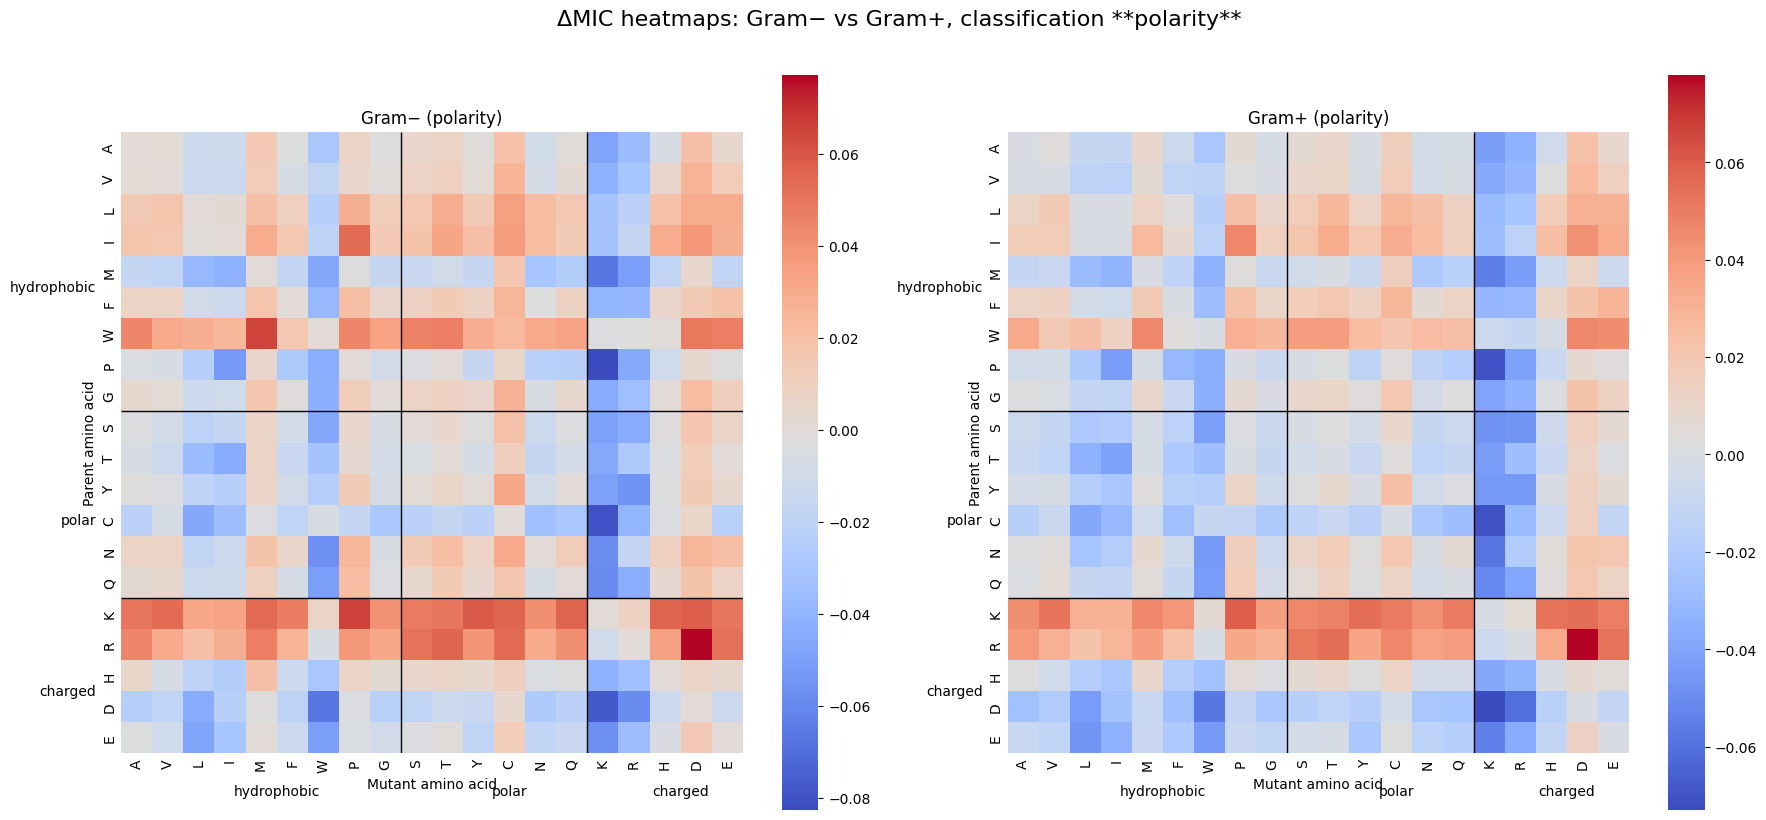

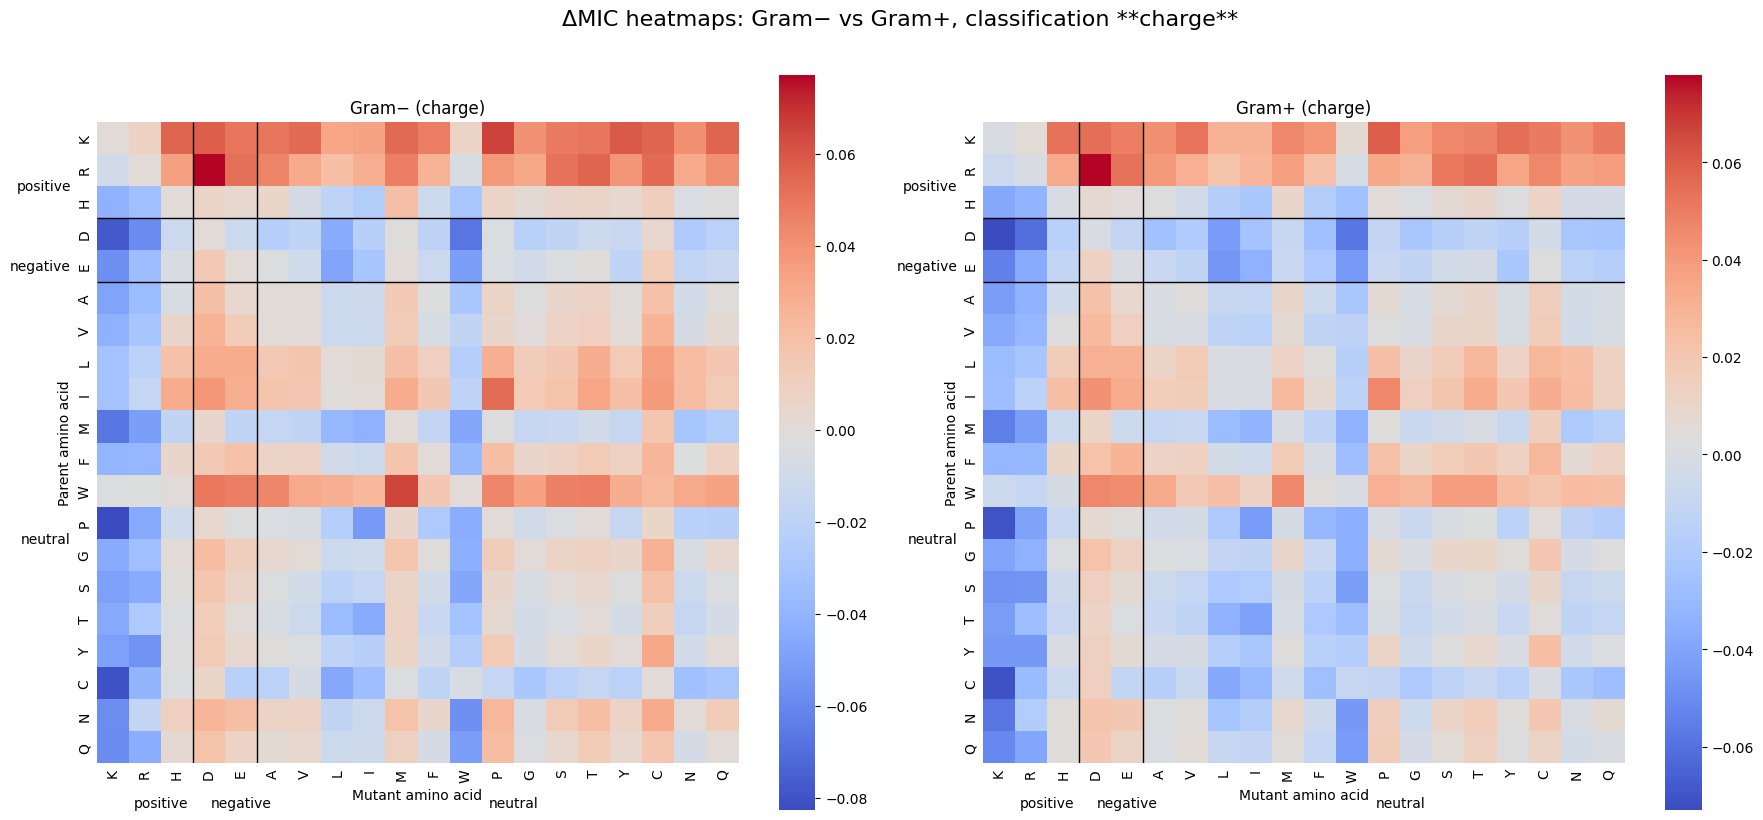

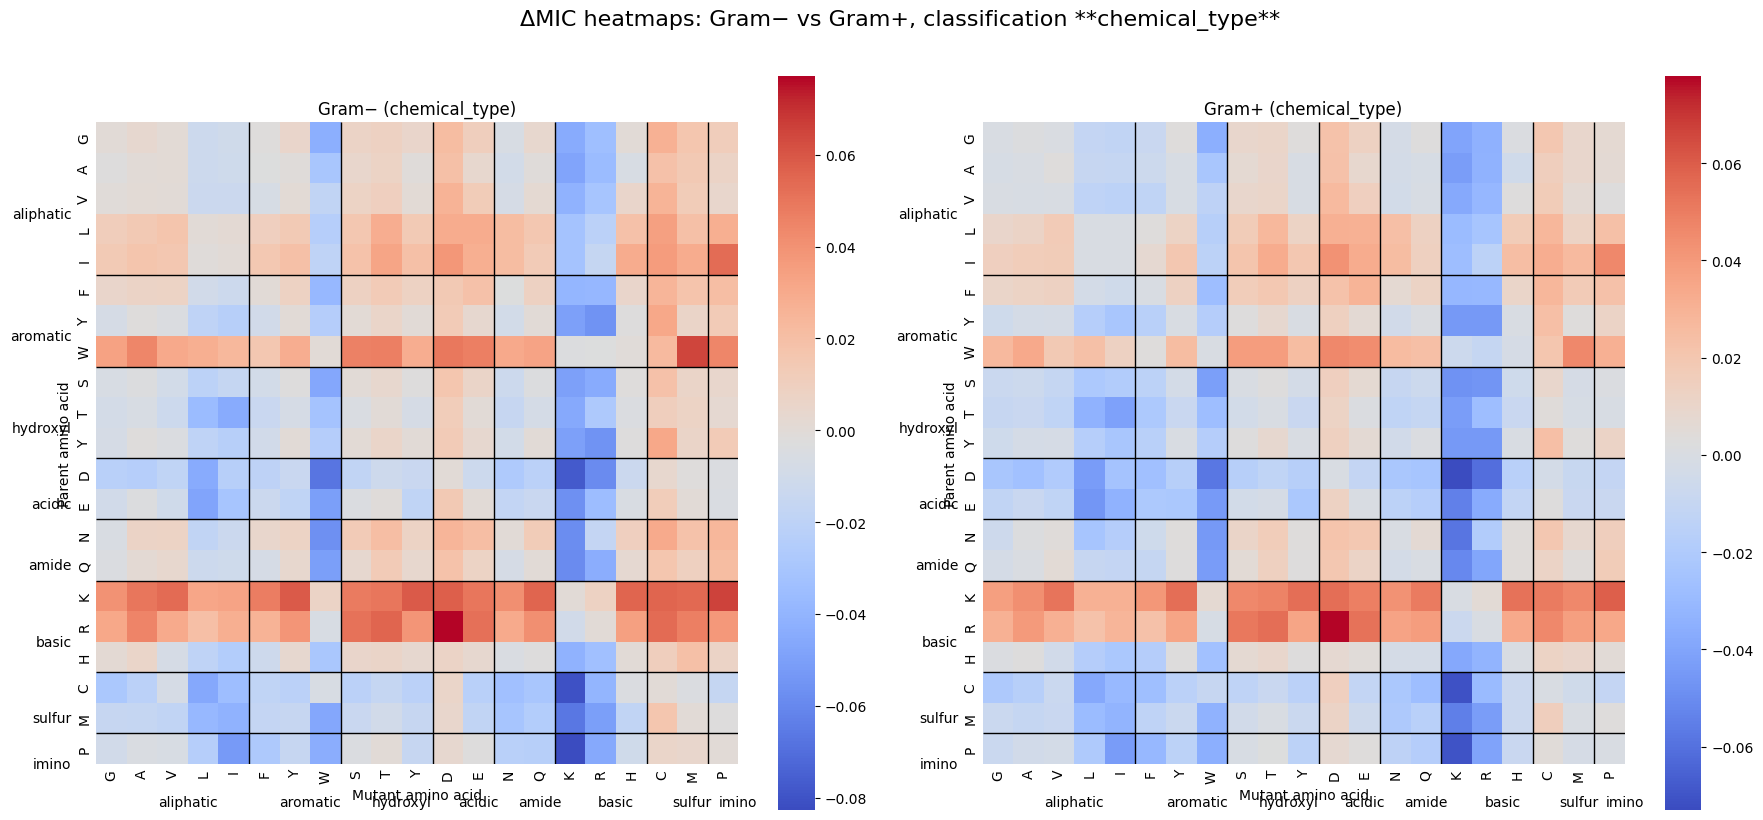

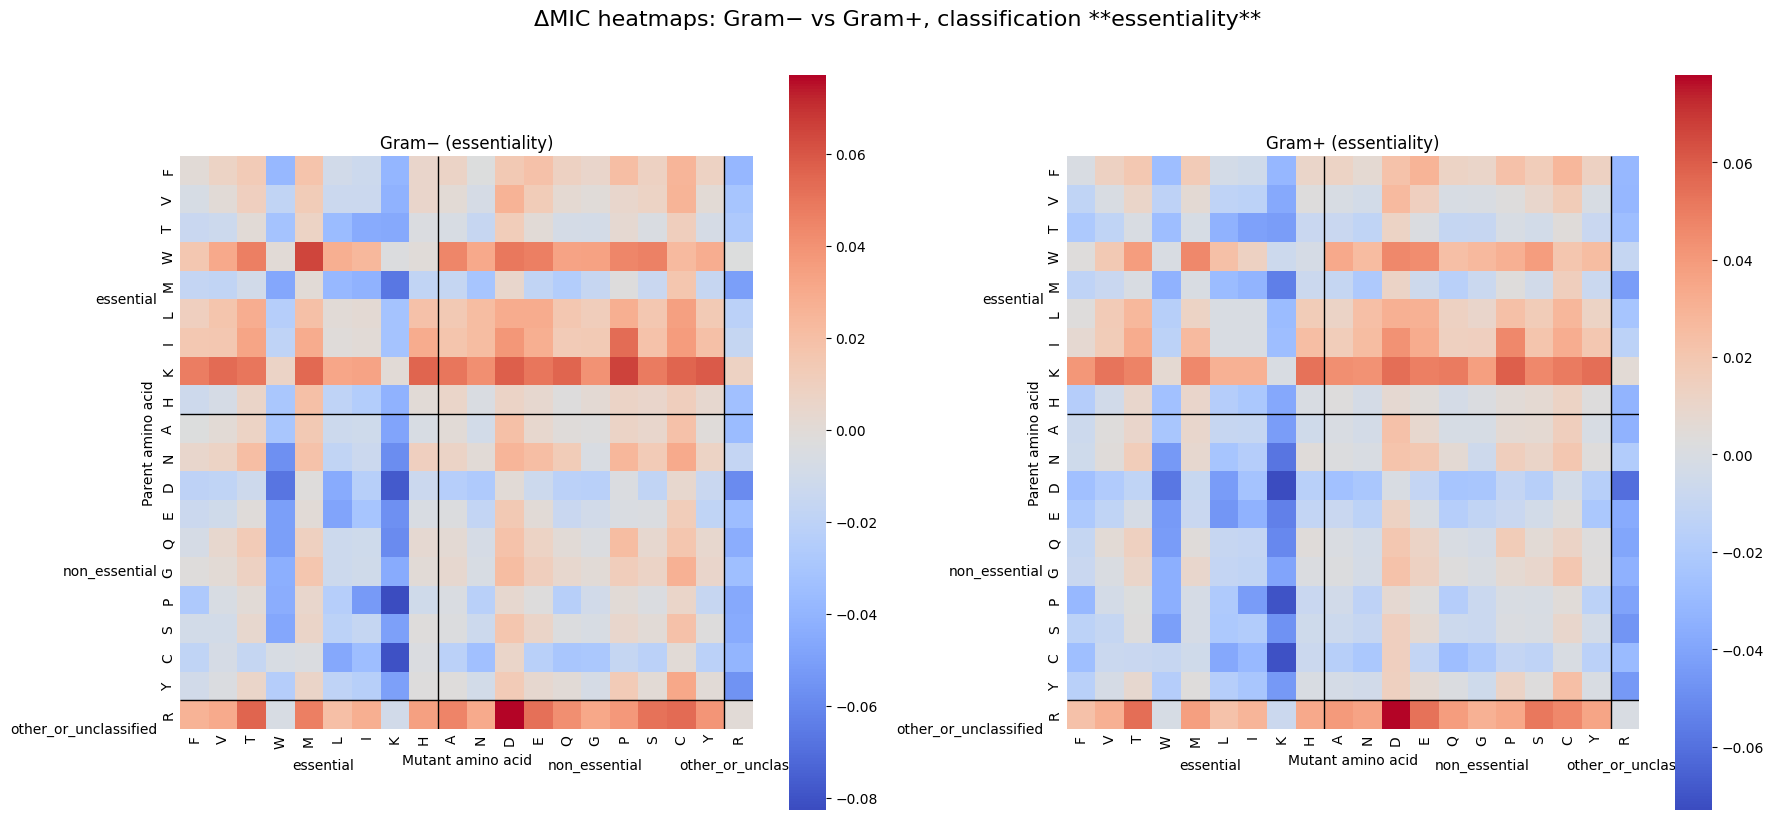

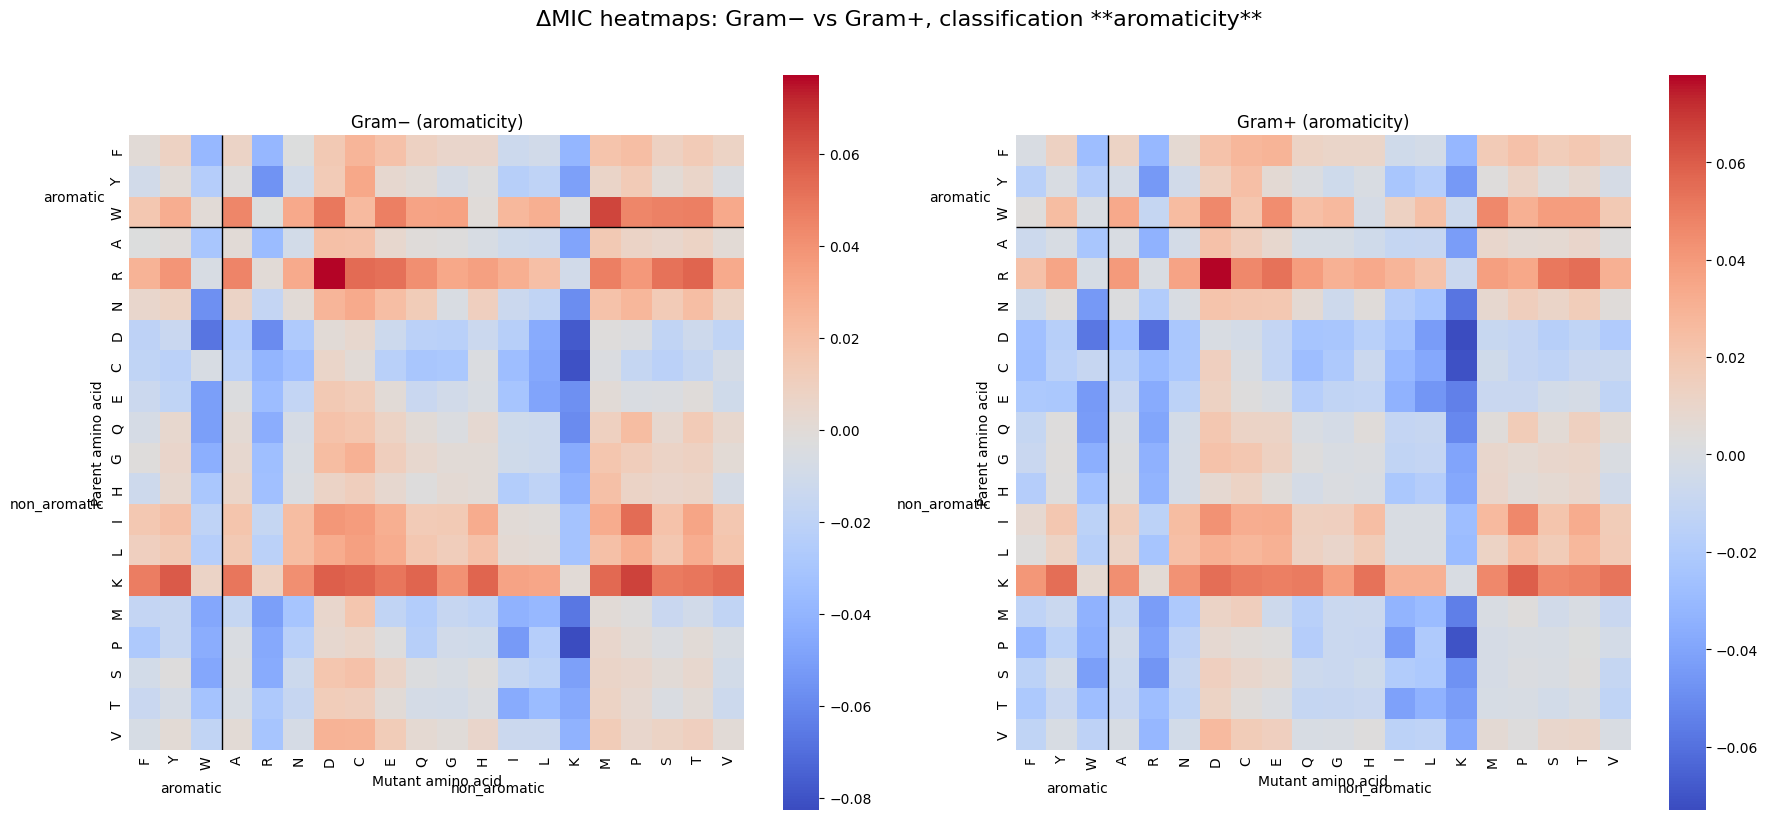

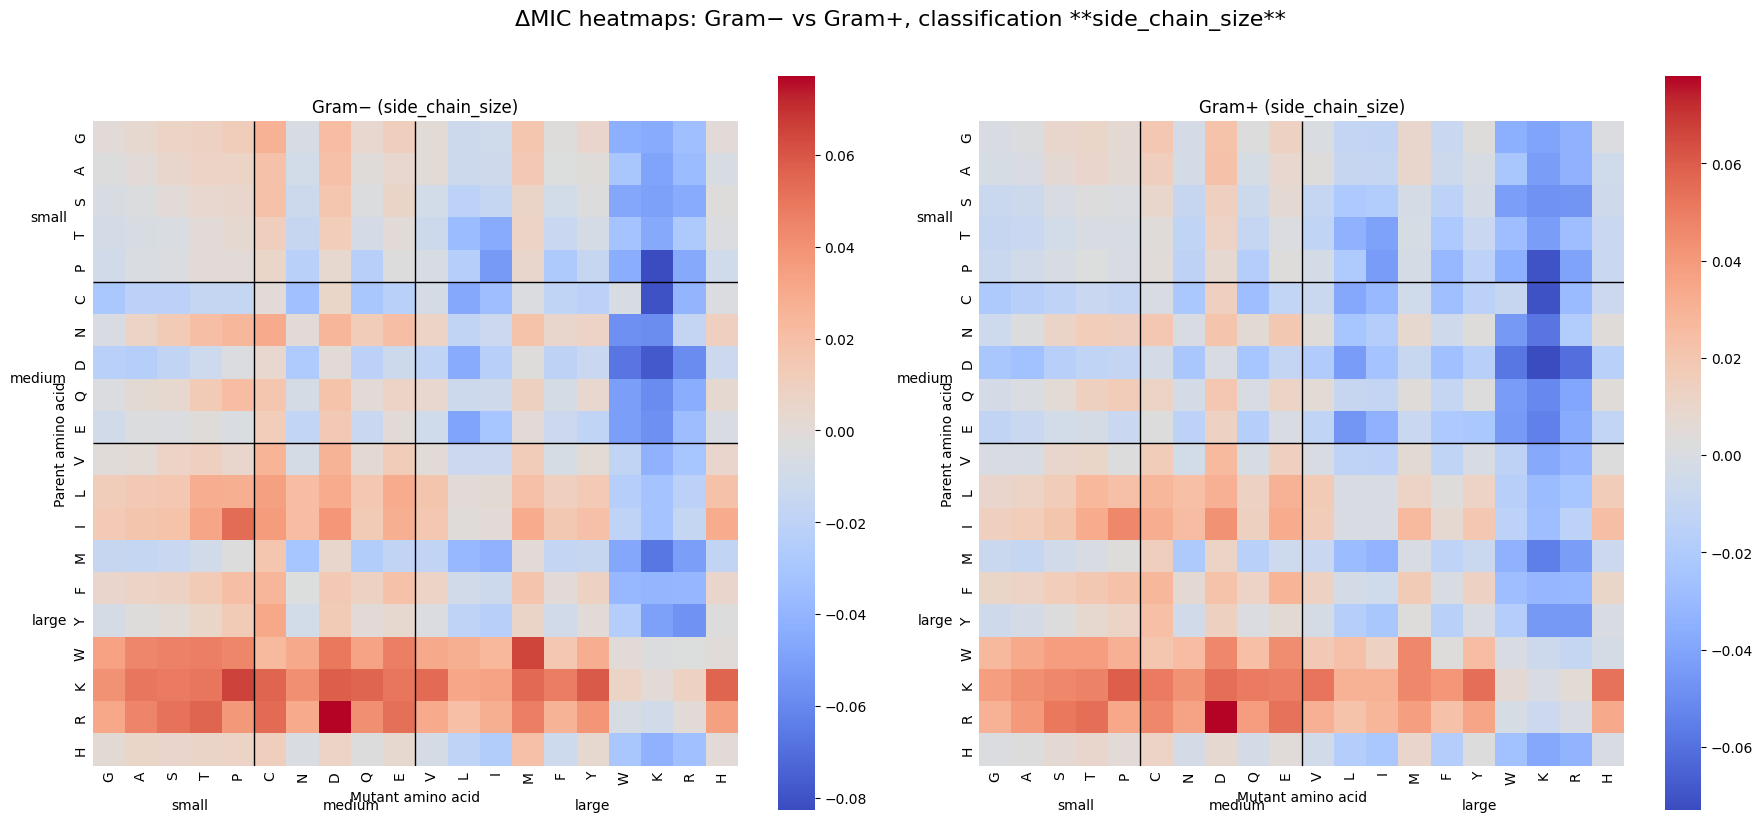

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from typing import Optional



def create_square_plot(
    data: np.ndarray | pd.DataFrame,
    classification: Optional[str] = None,
    cmap: str = "coolwarm",
    title: Optional[str] = None,
    show_labels: bool = True,
    figsize=(10, 8),
    return_fig: Optional[bool] = None,
):
    """
    Create a sorted amino acid × amino acid heatmap. 
    Labels are drawn but plt.show() is skipped if return_fig=True.
    """
    data = np.asarray(data, dtype=float)
    n = data.shape[0]
    if n != data.shape[1]:
        raise ValueError("Input data must be a square matrix!")

    aas = ALL_AA if n == 20 else [f"AA{i+1}" for i in range(n)]
    df = pd.DataFrame(data, index=aas, columns=aas)

    sorted_aas = aas.copy()
    boundaries = []
    
    if classification is not None:
        if classification not in AMINO_ACID_CLASSES:
            raise ValueError(f"Unknown classification: {classification}")

        groups = AMINO_ACID_CLASSES[classification]
        sorted_group_names = list(groups.keys())

        # Compose sorted list
        sorted_aas = [aa for g in sorted_group_names for aa in groups[g] if aa in aas]
        missing = [aa for aa in aas if aa not in sorted_aas]
        sorted_aas.extend(missing)

        # Compute group sizes and filter zero-sized groups
        group_sizes = [len([aa for aa in groups[g] if aa in aas]) for g in sorted_group_names]
        filtered_sizes = []
        for size in group_sizes:
            if size > 0:
                filtered_sizes.append(size)
        group_sizes = filtered_sizes

        if group_sizes:
            boundaries = np.cumsum(group_sizes)

    df_sorted = df.reindex(index=sorted_aas, columns=sorted_aas)

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(df_sorted, cmap=cmap, square=True, cbar=True, ax=ax,
                xticklabels=sorted_aas, yticklabels=sorted_aas)

    if title is None:
        title = f"Amino acid × amino acid ({classification})" if classification else "Amino acid × amino acid (unsorted)"
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Mutant amino acid")
    ax.set_ylabel("Parent amino acid")
    
    # Draw group boundaries (still necessary for return_fig=True to pass boundary info)
    if boundaries.size > 0:
        n_cells = len(sorted_aas)
        for b in boundaries[:-1]:
            ax.hlines(b, xmin=0, xmax=n_cells, colors="black", linewidth=1)
            ax.vlines(b, ymin=0, ymax=n_cells, colors="black", linewidth=1)

    # Note: Labels are drawn here, but only boundaries are strictly necessary 
    # to pass back for the combined plot re-draw. 
    # The combined plot logic handles labels separately.

    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.tick_params(axis="both", which="both", length=0)

    plt.tight_layout()

    if return_fig:
        return fig, ax, df_sorted, sorted_aas, boundaries
    else:
        plt.show()
        return None

# --- 3. HELPER FUNCTION TO RE-APPLY LABELS (CRITICAL FOR COMBINED PLOT) ---

def add_group_labels(ax, classification, sorted_aas, n_cells, show_labels=True):
    """Adds group labels to the left and bottom of an axis based on classification."""
    if not show_labels or classification not in AMINO_ACID_CLASSES:
        return

    groups = AMINO_ACID_CLASSES[classification]
    sorted_group_names = list(groups.keys())
    
    # Calculate group sizes based on what's present in sorted_aas
    group_sizes = [len([aa for aa in groups[g] if aa in sorted_aas]) for g in sorted_group_names]
    
    # Filter out zero-sized groups and their names
    final_group_names = []
    final_group_sizes = []
    for name, size in zip(sorted_group_names, group_sizes):
        if size > 0:
            final_group_names.append(name)
            final_group_sizes.append(size)
            
    if not final_group_sizes:
        return

    # Calculate midpoints for label placement
    starts = np.concatenate(([0], np.cumsum(final_group_sizes)[:-1]))
    mids = starts + np.array(final_group_sizes) / 2.0

    # Left side labels (y axis)
    x_left = -0.8 
    for mid, g in zip(mids, final_group_names):
        ax.text(
            x_left,
            mid + 0.5,
            g,
            va="center",
            ha="right",
            fontsize=10,
            transform=ax.transData,
            clip_on=False,
        )

    # Bottom labels (x axis)
    y_bottom = n_cells + 1.0 
    for mid, g in zip(mids, final_group_names):
        ax.text(
            mid + 0.5,
            y_bottom,
            g,
            va="top",
            ha="center",
            fontsize=10,
            transform=ax.transData,
            clip_on=False,
        )


# --- 4. PLOTTING LOOP ---

for c in classes:
    # 1. Get figs + sorted dfs (Individual figures are generated but not shown)
    fig_neg, ax_neg, df_neg_sorted, sorted_aas, boundaries_neg = create_square_plot(
        mean_gram_neg_matrix.astype(float).to_numpy(),
        classification=c,
        cmap="coolwarm",
        title="Gram-negative mean ΔMIC",
        return_fig=True,
        show_labels=True,
    )

    fig_pos, ax_pos, df_pos_sorted, _, boundaries_pos = create_square_plot(
        mean_gram_pos_matrix.astype(float).to_numpy(),
        classification=c,
        cmap="coolwarm",
        title="Gram-positive mean ΔMIC",
        return_fig=True,
        show_labels=True,
    )

    # Close the intermediate single figures
    plt.close(fig_neg)
    plt.close(fig_pos)

    # 2. Plot side-by-side using the sorted DataFrames directly
    fig_combined, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    sns.heatmap(df_neg_sorted, cmap="coolwarm", square=True, ax=axes[0],
                xticklabels=sorted_aas, yticklabels=sorted_aas)
    
    sns.heatmap(df_pos_sorted, cmap="coolwarm", square=True, ax=axes[1],
                xticklabels=sorted_aas, yticklabels=sorted_aas)

    # 3. Re-draw boundaries for combined axes
    n = len(sorted_aas)
    for b in boundaries_neg[:-1]:
        axes[0].hlines(b, xmin=0, xmax=n, colors="black", linewidth=1)
        axes[0].vlines(b, ymin=0, ymax=n, colors="black", linewidth=1)
        
    for b in boundaries_pos[:-1]: 
        axes[1].hlines(b, xmin=0, xmax=n, colors="black", linewidth=1)
        axes[1].vlines(b, ymin=0, ymax=n, colors="black", linewidth=1)
        
    # 4. 🔥 ADD GROUP LABELS 🔥
    add_group_labels(axes[0], c, sorted_aas, n, show_labels=True)
    add_group_labels(axes[1], c, sorted_aas, n, show_labels=True)
    
    # 5. Set titles and finalize plot
    axes[0].set_title(f"Gram− ({c})")
    axes[1].set_title(f"Gram+ ({c})")
    for ax in axes:
        ax.set_xlabel("Mutant amino acid")
        ax.set_ylabel("Parent amino acid")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
        ax.tick_params(axis="both", which="both", length=0)

    fig_combined.suptitle(f"ΔMIC heatmaps: Gram− vs Gram+, classification **{c}**", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()